TensorFlow version: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training samples: 10000
Testing samples: 2000
Train shape: (8000, 32, 32, 3)
Validation shape: (2000, 32, 32, 3)
Test shape: (2000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.5694 - loss: 0.6788 - val_accuracy: 0.5885 - val_loss: 0.6701
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.6242 - loss: 0.6450 - val_accuracy: 0.6360 - val_loss: 0.6470
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.6510 - loss: 0.6222 - val_accuracy: 0.6810 - val_loss: 0.5999
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.6702 - loss: 0.6078 - val_accuracy: 0.6755 - val_loss: 0.6029
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.6883 - loss: 0.5867 - val_accuracy: 0.6970 - val_loss: 0.5808


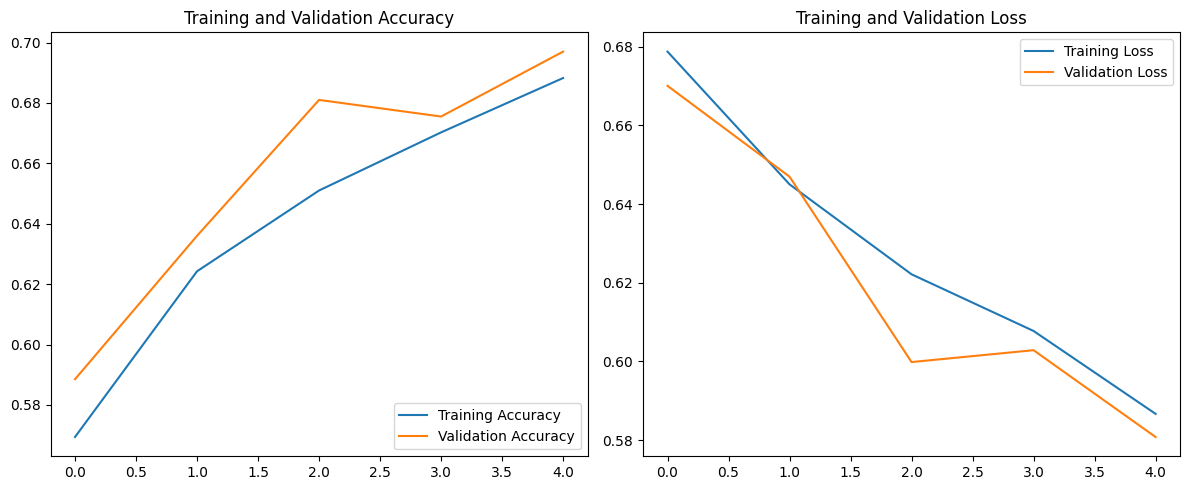

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6925 - loss: 0.5754
Test Accuracy: 0.6925
Test Loss: 0.5754

Classification Report:
              precision    recall  f1-score   support

         cat       0.73      0.62      0.67      1000
         dog       0.67      0.77      0.71      1000

    accuracy                           0.69      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.70      0.69      0.69      2000



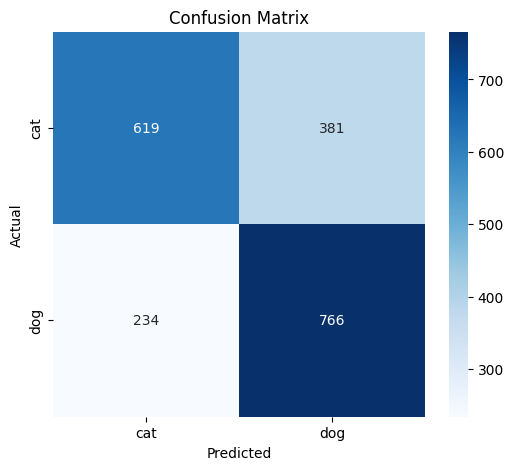

Model saved as /content/task2_simple_cnn_cats_dogs.keras


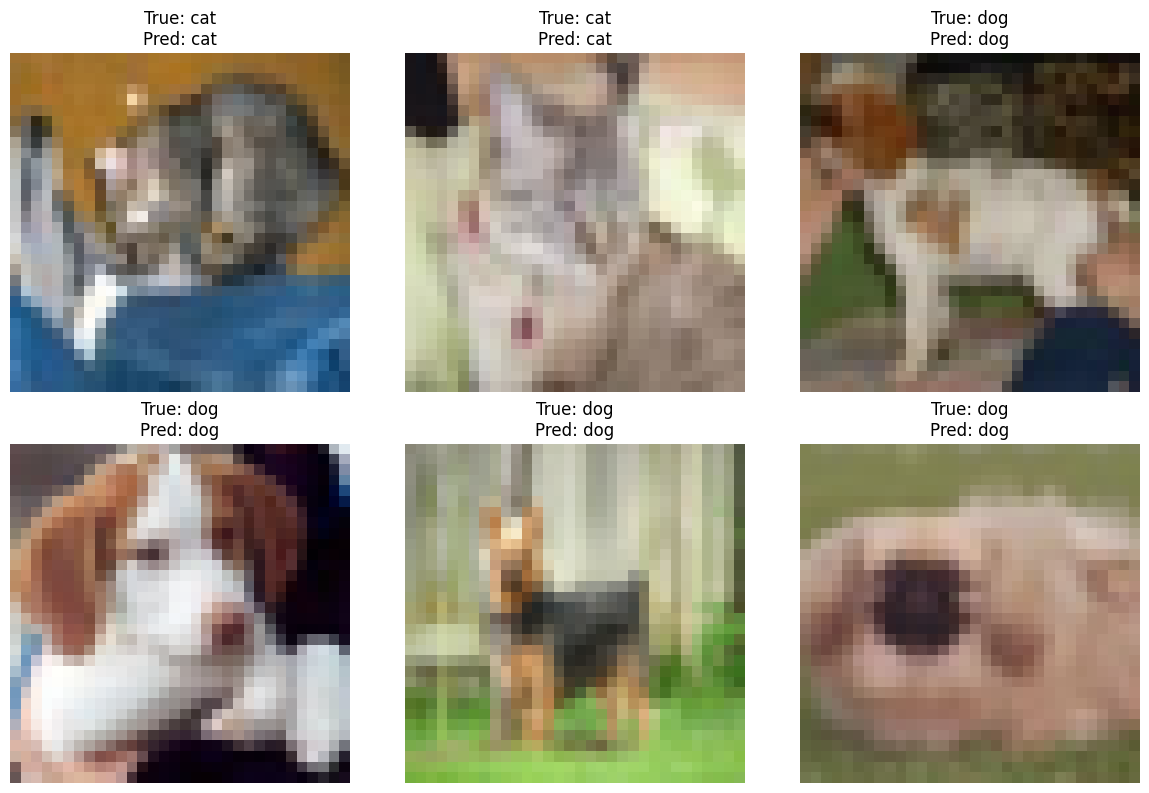

Saved model loaded successfully.


In [ ]:
# Task 2: Simple Deep Learning Image Classification (Google Colab)
# Alfido Tech AI Internship

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow version:', tf.__version__)

# =========================
# 1. Load CIFAR-10 Dataset
# =========================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use only 2 classes for simplicity: cat (3) and dog (5)
train_filter = np.where((y_train == 3) | (y_train == 5))[0]
test_filter = np.where((y_test == 3) | (y_test == 5))[0]

x_train, y_train = x_train[train_filter], y_train[train_filter]
x_test, y_test = x_test[test_filter], y_test[test_filter]

# Convert labels: cat=0, dog=1
y_train = np.where(y_train == 3, 0, 1)
y_test = np.where(y_test == 3, 0, 1)

class_names = ['cat', 'dog']

print('Training samples:', x_train.shape[0])
print('Testing samples:', x_test.shape[0])

# =========================
# 2. Normalize Data
# =========================
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Split validation set
x_val = x_train[-2000:]
y_val = y_train[-2000:]
x_train = x_train[:-2000]
y_train = y_train[:-2000]

print('Train shape:', x_train.shape)
print('Validation shape:', x_val.shape)
print('Test shape:', x_test.shape)

# =========================
# 3. Data Augmentation
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# =========================
# 4. Build Simple CNN Model
# =========================
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 5. Train Model
# =========================
EPOCHS = 5
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=32
)

# =========================
# 6. Plot Training Curves
# =========================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

# =========================
# 7. Evaluate Model
# =========================
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# =========================
# 8. Predictions and Metrics
# =========================
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = y_test.flatten()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# =========================
# 9. Save Model
# =========================
model.save('/content/task2_simple_cnn_cats_dogs.keras')
print('Model saved as /content/task2_simple_cnn_cats_dogs.keras')

# =========================
# 10. Sample Predictions
# =========================
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[int(y_true[i])]
    pred_label = class_names[int(y_pred[i])]
    plt.title(f'True: {true_label}\nPred: {pred_label}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# =========================
# 11. Load Saved Model
# =========================
loaded_model = tf.keras.models.load_model('/content/task2_simple_cnn_cats_dogs.keras')
print('Saved model loaded successfully.')